<a href="https://colab.research.google.com/github/Swatantraraj19/Soil-Analysis-and-Prediction-Using-Machine-Learning-and-VNIR-Spectroscopy-Data/blob/main/Project_ElasticNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import make_pipeline
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
data = pd.read_csv("/content/drive/MyDrive/Soil Analysis Project/ngp_dataset_copy.csv")

Mounted at /content/drive


/tmp/ipykernel_3112/2448831150.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/drive/MyDrive/Soil Analysis Project/ngp_dataset_copy.csv")


In [4]:
data.shape

(258, 2156)

In [5]:
data.head()

,SSN,phExtract,Ec Extract,CaCO3 equivalent %,oc,350,351,352,353,354,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,S1,9.71,8.60,2.13,0.10,0.046108,0.045455,0.047377,0.047641,0.047244,...,0.361984,0.362534,0.367887,0.373615,0.372376,0.368952,0.369218,0.369831,0.368443,0.366677
1,S2,9.31,10.98,2.00,0.16,0.058354,0.056818,0.060466,0.059517,0.056903,...,0.432295,0.431881,0.432052,0.431516,0.430653,0.429207,0.428507,0.427753,0.427360,0.428772
2,S3,10.06,11.40,4.63,0.33,0.054272,0.053030,0.054444,0.054254,0.053800,...,0.383106,0.380261,0.384512,0.392465,0.392107,0.386532,0.382463,0.379579,0.381684,0.384766
3,S4,9.69,7.54,9.13,0.30,0.057146,0.053030,0.054444,0.052904,0.050697,...,0.396354,0.390753,0.391703,0.395259,0.397433,0.400544,0.401183,0.399556,0.398051,0.395273
4,S5,9.75,5.16,12.63,0.25,0.063643,0.064394,0.067533,0.067480,0.066212,...,0.462253,0.463458,0.463963,0.463574,0.464622,0.465143,0.461718,0.457439,0.456462,0.456705


In [6]:
X = data.iloc[:119, 5:]    # Features ( spectroscopy data )
y = data.iloc[:119, 4]   # Target variable (Soil Organic Carbon)

In [7]:
# original wavelengths
wavelengths = X.columns.astype(float)

# target fixed wavelengths (500 points)
target_wavelengths = np.linspace(350, 2500, 500)

def resample(df):
    resampled = []
    for _, row in df.iterrows():
        f = interp1d(wavelengths, row.values,
                     kind='linear', fill_value="extrapolate")
        resampled.append(f(target_wavelengths))
    return np.array(resampled)

In [8]:
X_resampled = resample(X)

In [9]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y, test_size=0.2, random_state=42)

In [10]:


pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [11]:
# Feature scaling
sc_X = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train_pca)
X_test_scaled = sc_X.transform(X_test_pca)

In [12]:
# Train ElasticNet model
elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.35)
elastic_net.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.01, l1_ratio=0.35)

In [13]:
# Predict SOC for test set
y_pred = elastic_net.predict(X_test_scaled)

In [14]:
# Compare the Test Set with Predicted Values
comparison_df = pd.DataFrame({'Actual_SOC': y_test.ravel(), 'Predicted_SOC': y_pred.ravel()})
print(comparison_df)

    Actual_SOC  Predicted_SOC
0         0.47       0.387476
1         0.32       0.188577
2         0.25       0.206117
3         0.42       0.396375
4         0.51       0.329204
5         0.19       0.193260
6         0.26       0.172202
7         0.46       0.479807
8         0.44       0.047644
9         0.26       0.262267
10        0.51       0.384486
11        0.11       0.162305
12        0.51       0.473664
13        0.36       0.294502
14        0.51       0.548246
15        0.49       0.436164
16        0.30       0.303802
17        0.10       0.387503
18        0.36       0.353312
19        0.06       0.090589
20        0.57       0.527915
21        0.42       0.313113
22        0.55       0.348971
23        0.49       0.512773


/tmp/ipykernel_3112/4110809650.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  comparison_df = pd.DataFrame({'Actual_SOC': y_test.ravel(), 'Predicted_SOC': y_pred.ravel()})


In [15]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.016148080789578776


In [16]:
import math
rmse = math.sqrt(mse)
print("Root Mean Squared Value:", rmse)

Root Mean Squared Value: 0.127075099014633


In [17]:
from sklearn.metrics import r2_score

# Calculate R2 score
r2 = r2_score(y_test, y_pred)
print("R-squared (R2) Score:", r2)

R-squared (R2) Score: 0.25860106054733334


In [18]:
# Import the necessary function
from sklearn.metrics import mean_absolute_error

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.08503458891951073


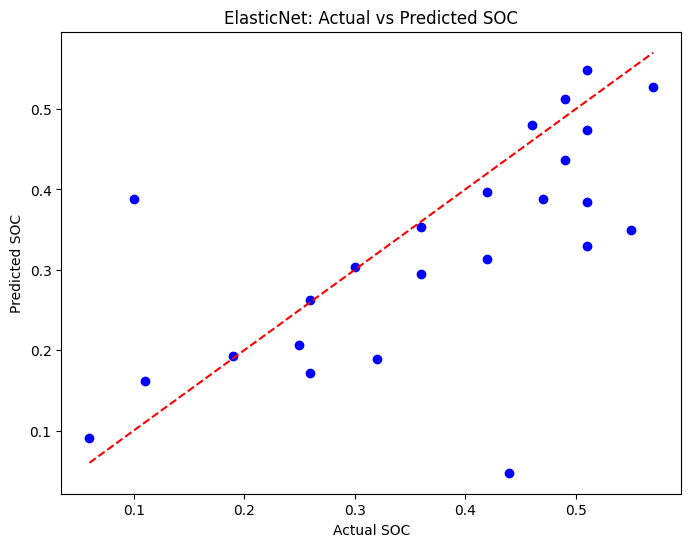

In [19]:
import matplotlib.pyplot as plt
# Scatter plot of actual vs predicted SOC values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual SOC')
plt.ylabel('Predicted SOC')
plt.title('ElasticNet: Actual vs Predicted SOC')
plt.show()

In [20]:
import pickle

pickle.dump(elastic_net, open("model.pkl", "wb"))
pickle.dump(sc_X, open("scaler.pkl", "wb"))
pickle.dump(pca, open("pca.pkl", "wb"))
pickle.dump(target_wavelengths, open("wavelengths.pkl", "wb"))